# Getting started with the Embed endpoint

## Overview
Text embeddings convert words and sentences into numerical representations that capture semantic meaning, enabling machines to process and compare text mathematically. The Embed endpoint provides a powerful way to generate these embeddings for various natural language processing tasks. This tutorial demonstrates how to use Cohere's Embed endpoint to create embeddings, compute text similarities, and explore advanced features like multilingual support and different embedding types.

This tutorial demonstrates how to use Cohere's Embed endpoint to generate text embeddings and compute semantic similarities.

By the end, you will be able to generate embeddings, calculate text similarities, and work with different embedding configurations.


## What we'll cover
- Using the Embed endpoint
- Examining response object structure
- Computing similarity measures
- Working with multilingual text

# Quick embed endpoint test

In [1]:
import cohere
import os
from dotenv import load_dotenv
load_dotenv(override=True)

MODEL = os.environ["EMBED_MODEL"]
co = cohere.ClientV2(
    base_url=os.environ["EMBED_BASE_URL"],
    api_key=os.environ["EMBED_API_KEY"],
    timeout=300,
)

texts = [
    "The quick brown fox jumps over the lazy dog",
    "Artificial intelligence is transforming every industry",
]

response = co.embed(
    model=MODEL,   # embed-v-4-0
    texts=texts,
    input_type="search_document",
)

print('The embed endpoint should generate vectors for each text string.   If you get errors here, check your .env file for correctness.\n')
for i, (text, emb) in enumerate(zip(texts, response.embeddings.float)):
    print(f"Text {i+1}: {text}")
    print(f"  Dim: {len(emb)}, first 5: {emb[:5]}")

The embed endpoint should generate vectors for each text string.   If you get errors here, check your .env file for correctness.

Text 1: The quick brown fox jumps over the lazy dog
  Dim: 1536, first 5: [0.0026550293, -0.010864258, -0.024169922, -0.00024223328, -0.033203125]
Text 2: Artificial intelligence is transforming every industry
  Dim: 1536, first 5: [0.025146484, 0.029541016, 0.0043945312, -0.029296875, 0.022705078]


## Using the Embed endpoint

In [2]:
import numpy as np
import seaborn as sns

# Define the documents
documents = [
    "I like to be in my house",
    "I enjoy staying home",
    "the isotope 238u decays to 206pb"
]

# Embed the documents
doc_emb = co.embed(
    model=os.environ["EMBED_MODEL"],
    input_type="search_document",
    texts=documents,
    embedding_types=["float"],
).embeddings.float

## Similarity measure

In [3]:
[sentence1, sentence2, sentence3] = doc_emb

print("Embedding for sentence 1", np.array(sentence1))
print("Embedding for sentence 2", np.array(sentence2))
print("Embedding for sentence 3", np.array(sentence3))

Embedding for sentence 1 [ 0.01770019 -0.0246582  -0.02844238 ...  0.0123291  -0.03344727
  0.00072479]
Embedding for sentence 2 [ 0.01135254 -0.03466797 -0.05761719 ...  0.0168457   0.00823975
  0.00212097]
Embedding for sentence 3 [ 0.0112915   0.01202393  0.0067749  ... -0.02441406 -0.04589844
 -0.0324707 ]


In [4]:
print("Similarity between sentences 1 and 2:", np.dot(sentence1, sentence2))
print("Similarity between sentences 1 and 3:", np.dot(sentence1, sentence3))
print("Similarity between sentences 2 and 3:", np.dot(sentence2, sentence3))

Similarity between sentences 1 and 2: 0.7462707202852605
Similarity between sentences 1 and 3: 0.19362619488192492
Similarity between sentences 2 and 3: 0.218420468808871


[Text(0.5, 0, 'I like to be in my house'),
 Text(1.5, 0, 'I enjoy staying home'),
 Text(2.5, 0, 'the isotope 238u decays to 206pb')]

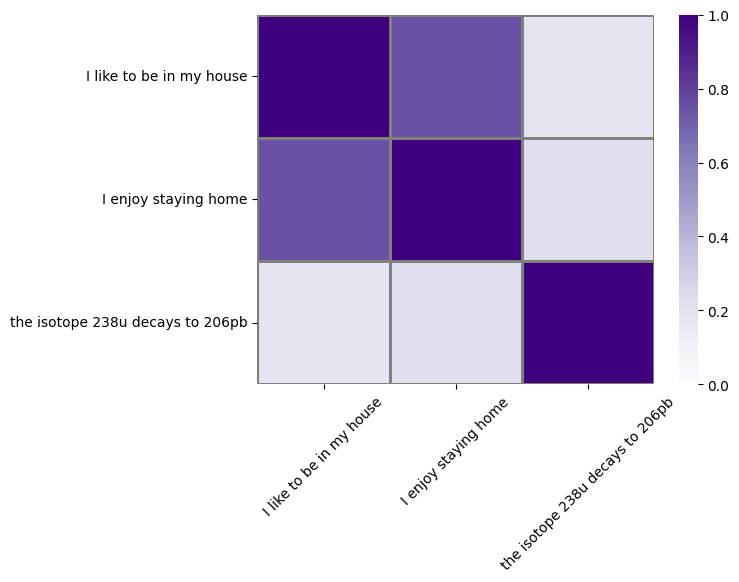

In [5]:
# Get pairwise dot product similarities
dot_products = [
    [np.dot(doc_emb[i], doc_emb[j]) for i in range(len(doc_emb))]
    for j in range(len(doc_emb))
]

# Plot in 3x3 grid
ax = sns.heatmap(
    dot_products,
    vmin=0,
    vmax=1,
    linewidths=1,
    linecolor="grey",
    xticklabels=documents,
    yticklabels=documents,
    cmap="Purples"
)
ax.set_xticklabels(labels=documents, rotation=45)

## Multilingual support

[Text(0.5, 0, 'I like to be in my house'),
 Text(1.5, 0, '집에 있는 것을 좋아해요'),
 Text(2.5, 0, 'the isotope 238u decays to 206pb')]

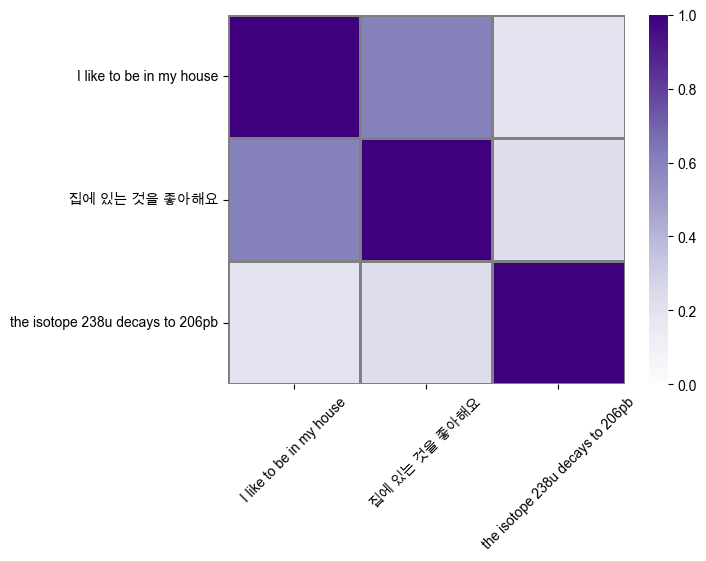

In [6]:
# https://docs.cohere.com/v2/docs/cohere-embed#list-of-supported-languages
# # Settings to support rendering fonts
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = ['Arial Unicode MS']

# Define the documents
documents = [
    "I like to be in my house",
    "집에 있는 것을 좋아해요", # I like being at home
    "the isotope 238u decays to 206pb"
]

# Embed the documents
doc_emb = co.embed(
    model=MODEL,
    input_type="search_document",
    texts=documents,
    embedding_types=["float"],
).embeddings.float

# Get pairwise dot product similarities
dot_products = [
    [np.dot(doc_emb[i], doc_emb[j]) for i in range(len(doc_emb))]
    for j in range(len(doc_emb))
]

# Plot in 3x3 grid
ax = sns.heatmap(
    dot_products,
    vmin=0,
    vmax=1,
    linewidths=1,
    linecolor="grey",
    xticklabels=documents,
    yticklabels=documents,
    cmap="Purples"
)
ax.set_xticklabels(labels=documents, rotation=45)

## Conclusion
This tutorial covered the fundamentals of using Cohere's Embed endpoint, from basic embedding generation to advanced features like multilingual support and different embedding types. The examples demonstrated how to compute text similarities and work with various embedding configurations for different use cases.